In [1]:
import json
import pandas as pd
import mplfinance as mpf
from massive import RESTClient

In [ ]:
with open("api_key.json") as f:
    api_keys = json.load(f)

client = RESTClient(api_keys["massive"])
del api_keys

In [3]:
aggs = []
for a in client.list_aggs(
    "NVDA",
    1,
    "minute",
    "2025-12-01",
    "2025-12-03",
    limit=50000,
):
    aggs.append(a)

print(f"Downloaded {len(aggs)} data points")

Downloaded 1910 data points


In [4]:
# Convert to DataFrame
df = pd.DataFrame(aggs)
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df.set_index('timestamp', inplace=True)

# Rename columns to match mplfinance requirements
df.rename(columns={
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'close': 'Close',
    'volume': 'Volume'
}, inplace=True)

df.head()

,Open,High,Low,Close,Volume,vwap,transactions,otc
timestamp,,,,,,,,
2025-12-01 09:00:00,175.65,176.40,175.11,175.30,38069.0,175.5658,1233,None
2025-12-01 09:01:00,175.39,175.50,175.26,175.29,7170.0,175.3928,260,None
2025-12-01 09:02:00,175.20,175.21,175.06,175.12,13598.0,175.1487,391,None
2025-12-01 09:03:00,175.15,175.15,175.05,175.15,19263.0,175.1061,335,None
2025-12-01 09:04:00,175.11,175.15,175.11,175.15,4727.0,175.1342,158,None


/home/mrakgr/.venv/lib/python3.12/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


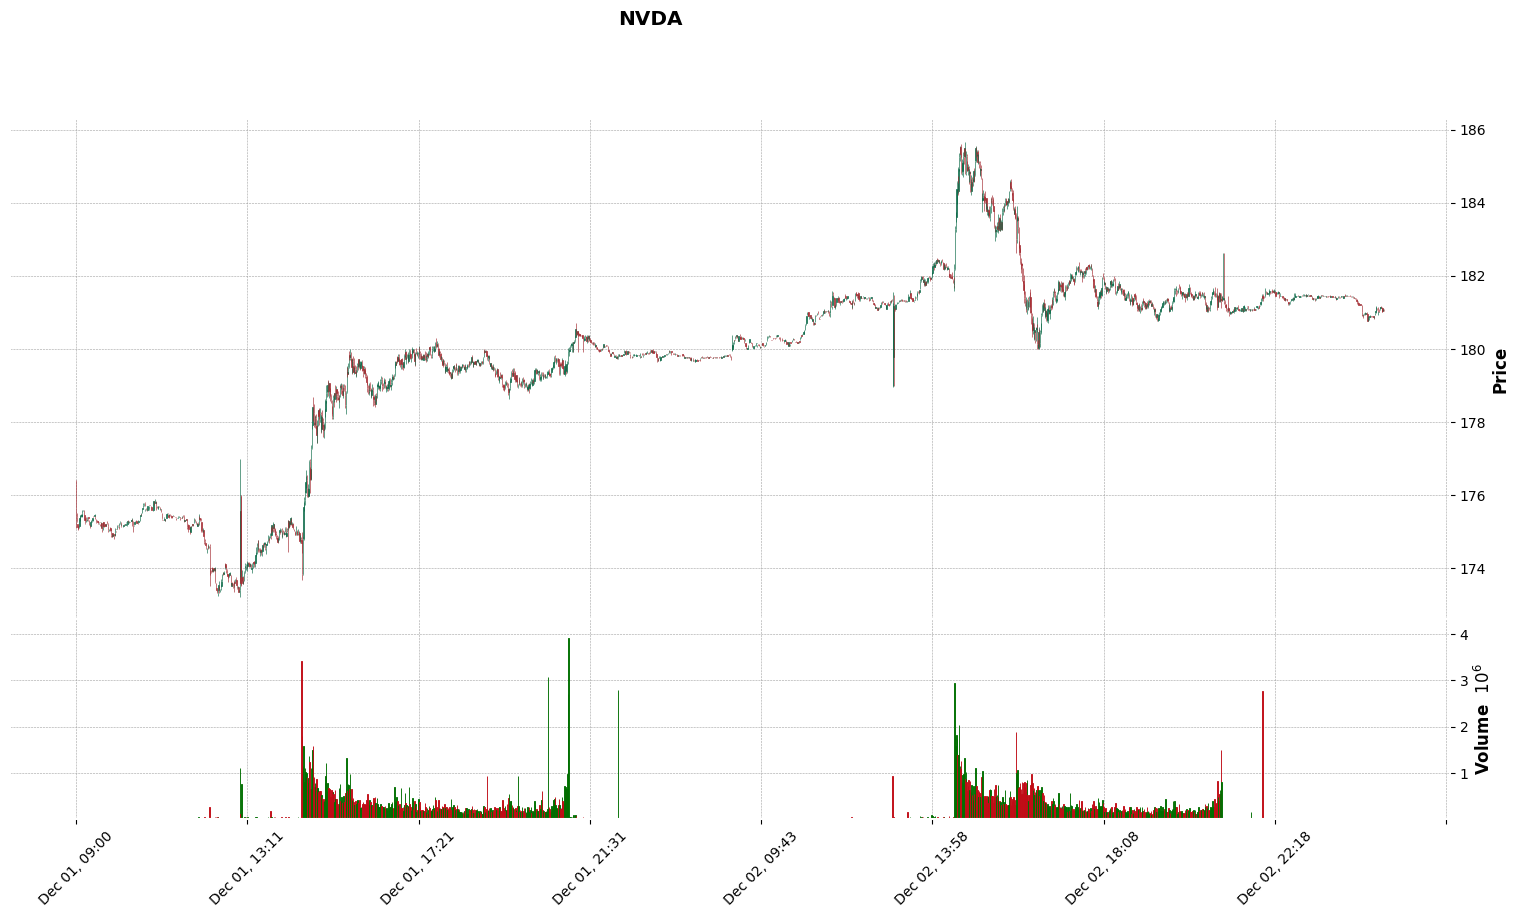

In [8]:
# Plot the data
mpf.plot(df, type='candle', style='charles', title='NVDA', volume=True, figsize=(20, 10))